# 1時間で理解する 畳み込みニューラルネットワーク (CNN) 入門

## 本日の目的
- 画像処理において全結合層（DNN）ではなく「畳み込み層（CNN）」が必要な理由を理解する。
- Keras (`tf.keras`) を使って簡単なCNNモデルを構築・学習・評価できるようになる。
- `SparseCategoricalCrossentropy` などの損失関数や出力層の仕組みを整理する。

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Matplotlibの表示設定 ---
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline') # VS Code / Jupyter用バックエンド
import matplotlib.pyplot as plt

%matplotlib inline

# 環境の確認
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. データセットの準備と前処理
CIFAR-10 データセット（32x32のカラー画像、10クラス）を使用します。
画素値（0~255）を 255.0 で割り、0.0~1.0 の範囲に正規化（Scaling）します。

In [11]:
import ssl

# SSL証明書の検証を一時的に無効化する
ssl._create_default_https_context = ssl._create_unverified_context

# データセットのロード
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 【重要】チャンネル（色）次元の追加
# Fashion-MNISTは(枚数, 28, 28)の2D形状のため、CNNのConv2Dに入力できるよう
# (枚数, 28, 28, 1) という「色チャンネル（1＝グレースケール）」の次元を np.newaxis 等で追加します。
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# データの正規化（Normalization）
# 元の画素値は 0~255（8bit整数）なので、255.0 で割って 0.0~1.0（浮動小数点数）に変換します。
# ※ ニューラルネットワークの重み更新（勾配降下法）を安定・高速化するために必須の作業です。
x_train, x_test = x_train / 255.0, x_test / 255.0

# 0〜9の数値ラベルに対応するクラス名（衣類の種類）を定義
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# shape属性: 配列の次元（形状）を確認する
# 画面出力例: 訓練画像形状: (60000, 28, 28, 1), 訓練ラベル形状: (60000,)
print(f"訓練画像形状: {x_train.shape}, 訓練ラベル形状: {y_train.shape}")

訓練画像形状: (60000, 28, 28, 1), 訓練ラベル形状: (60000,)


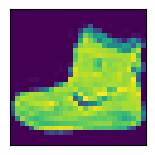

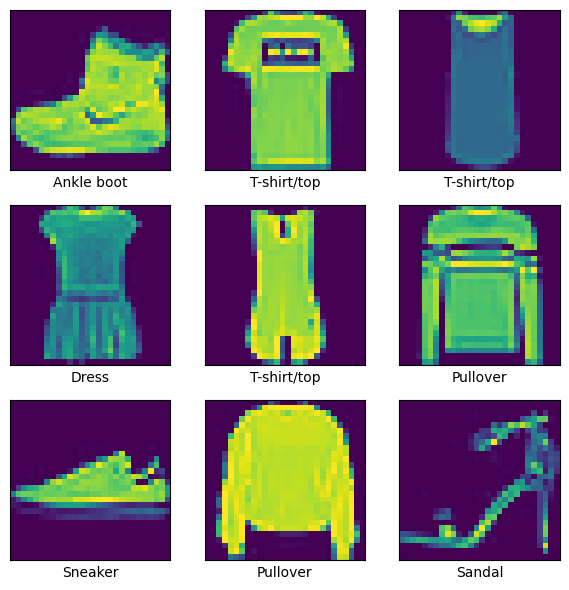

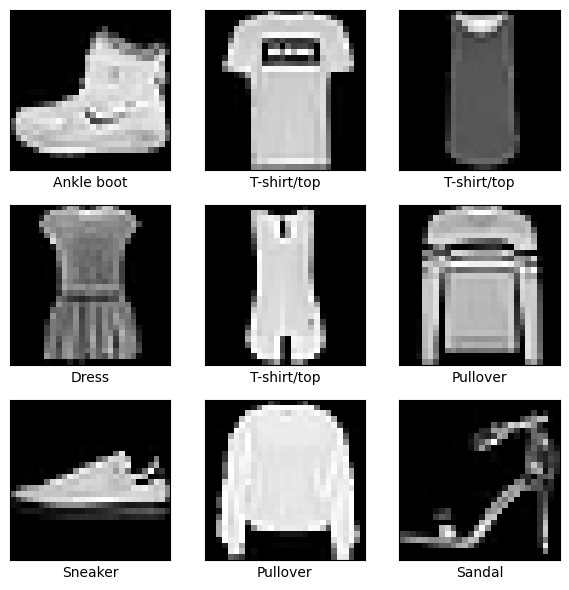

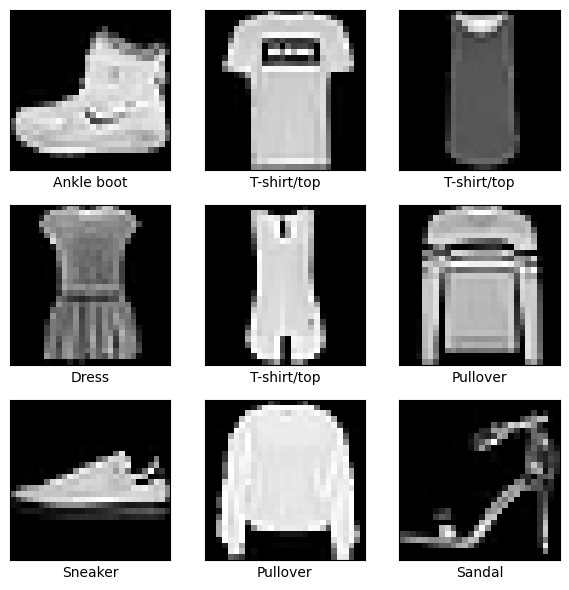

In [12]:
# 画像の描画（最初の9枚）
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # モノクロ画像（28, 28, 1）の描画
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    # 修正箇所: [0] を外して y_train[i] に変更
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

## 2. CNNモデルの構築
- `Conv2D`: フィルタ（Kernel）を用いて画像のエッジや模様などの局所特徴を抽出する。
- `MaxPooling2D`: 解像度を縮小し、位置のズレに対する耐久性を高めつつ計算量を減らす。
- `Flatten` & `Dense`: 抽出された2D特徴量を1Dに伸ばし、10クラスへ分類する全結合層へ繋ぐ。

In [15]:
model = models.Sequential([
    # 修正箇所: Fashion-MNIST 用に (28, 28, 1) に変更
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # 畳み込み層 2 + プーリング層 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 畳み込み層 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # 分類用の全結合層（出力層）
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)  # 10クラス分類（Logitsを出力）
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

### 💡 【補足】 損失関数・出力層の解説
コンパイル時に指定する `SparseCategoricalCrossentropy(from_logits=True)` について整理しておきましょう。

#### ① 「Sparse」の意味
- 正解ラベルのフォーマットによる違いです。
  - `SparseCategoricalCrossentropy`: 正解ラベルが数値インデックス（例: `3`, `7` など）。One-Hotエンコーディング不要。
  - `CategoricalCrossentropy`: 正解ラベルがOne-Hotベクトル（例: `[0, 0, 0, 1, 0...]`）。

#### ② 「from_logits=True」の意味
- **Logits（ロジッツ）**: モデルの最終層から出力される、Softmaxを通す前の**生のスカラー値（確率になっていない値）**のこと。
- 出力層で `activation='softmax'` を付けずに `from_logits=True` を指定すると、内部でSoftmax計算とCross-Entropy計算が数学的に統合されます。
- **なぜこうするのか？**: 別々で計算するよりも数値計算上の安定性（オーバーフロー・アンダーフロー防止）が高く、TensorFlow公式でも強く推奨されています。

In [16]:
# モデルのコンパイル
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 学習の実行（勉強会用に5エポック）
history = model.fit(
    x_train, y_train, 
    epochs=5, 
    validation_data=(x_test, y_test),
    batch_size=64
)

Epoch 1/5
148/938 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5035 - loss: 1.3800 

I0000 00:00:1785574635.804370 3855953 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.7959 - loss: 0.5531 - val_accuracy: 0.8544 - val_loss: 0.4028
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8713 - loss: 0.3538 - val_accuracy: 0.8713 - val_loss: 0.3527
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8895 - loss: 0.3039 - val_accuracy: 0.8846 - val_loss: 0.3166
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9008 - loss: 0.2712 - val_accuracy: 0.8895 - val_loss: 0.3073
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9096 - loss: 0.2474 - val_accuracy: 0.8998 - val_loss: 0.2800


## 3. 評価と可視化

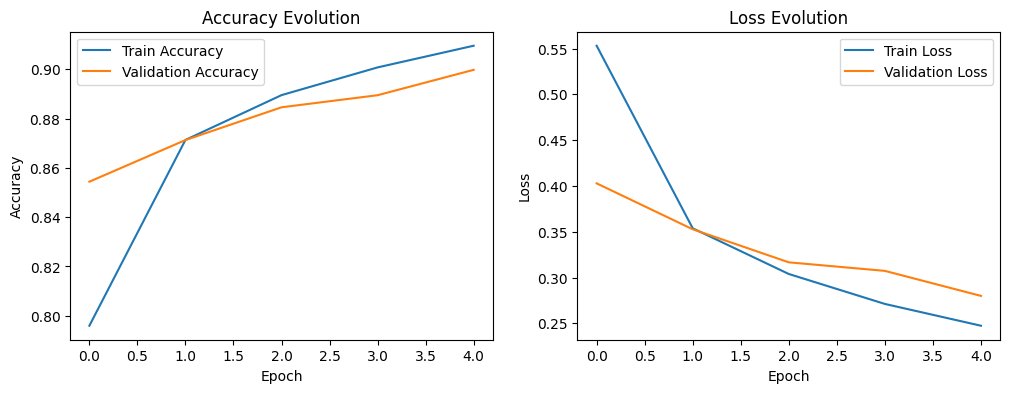

313/313 - 1s - 5ms/step - accuracy: 0.8998 - loss: 0.2800

テストデータの正解率 (Accuracy): 0.8998


In [17]:
# 学習曲線のプロット
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Evolution')

plt.show()

# テストデータ全体の評価
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nテストデータの正解率 (Accuracy): {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


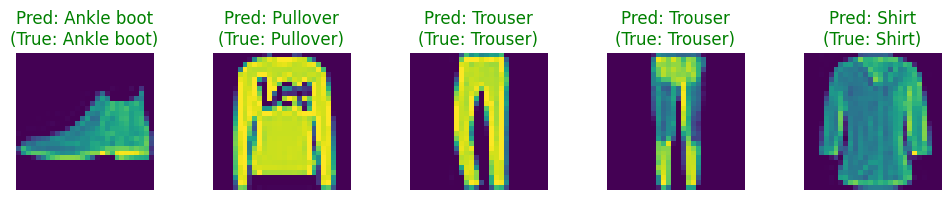

In [19]:
# モデル出力(Logits)にSoftmaxを適用して確率化し、推論テストを行う
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(x_test[:5])

# 最初の5枚の予測結果を描画
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i])
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\n(True: {true_label})", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()